In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

<h1 style="text-align: center; font-weight: bold;">
بِسْمِ ٱللَّٰهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ
</h1>

Full Name: Mohammadmahdi Bababeyk

Student ID: 4041419005

# Implementing Vision Transformer (ViT) from Scratch on CIFAR-10

### Objective
Implement a **Vision Transformer ** [(ViT)](https://arxiv.org/abs/2010.11929) to classify CIFAR-10 images *without using any high-level ViT libraries* (e.g., `timm`, `transformers`). You must build every component yourself: patch embedding, positional encoding, multi-head self-attention, MLP blocks, and the full encoder.

> **You are allowed to use only**: `torch`, `torch.nn`, `torch.optim`, `torchvision.datasets/transforms`, `numpy`, `matplotlib`.

### Model Specifications (Fixed – Do Not Change)
Use **exactly** these hyperparameters (designed for CIFAR-10’s small resolution):
| Component | Value |
|--------|------|
| Input image size | `32 × 32 × 3` (CIFAR-10) |
| Patch size | `4 × 4` |
| Number of patches | `(32/4)² = 64` |
| Embedding dimension (`embed_dim`) | `128` |
| Number of Transformer layers | `6` |
| Number of attention heads (`n_heads`) | `8` |
| MLP hidden dim (per block) | `256` |
| Dropout | `0.1` |
| Classification head | Linear layer (`128 → 10`) |
| Optimizer | `AdamW` (`lr=3e-4`, `weight_decay=0.05`) |
| LR scheduler | `CosineAnnealingLR` (`T_max=50`) |

### Required Modules to Implement
Implement the following PyTorch `nn.Module`s (with correct method signatures):

1. **`PatchEmbedding`**
   - Converts image `(B, C, H, W)` → sequence of patches `(B, N, embed_dim)`.
   - Use `Conv2d` with `kernel_size=patch_size`, `stride=patch_size`.
   - Output: `(B, N, embed_dim)`, where `N = (H // P) × (W // P)`.

2. **`MultiHeadAttention`**
   - Compute `Q`, `K`, `V` via one linear layer (`3 * embed_dim` output).
   - Split into `n_heads`, compute scaled dot-product attention.
   - Return output + **optionally attention weights** (for later visualization).
   - Use `softmax(dim=-1)` and scaling `1/√dₖ`.

3. **`MLP`**
   - Two-layer feedforward: `embed_dim → hidden_dim → embed_dim`.
   - Use `GELU`, not ReLU.
   - Apply dropout after each linear layer.

4. **`TransformerBlock`**
   - Pre-norm design:  
     `x + Attention(LayerNorm(x))`  
     `x + MLP(LayerNorm(x))`
   - Return attention weights *only if requested* (see hint below).

5. **`VisionTransformer` (Main Model)**
   - Steps:
     1. Patch embedding.
     2. Prepend learnable `[CLS]` token.
     3. Add **learnable** 1D positional embeddings (size `N+1`).
     4. Pass through `n_layers` of `TransformerBlock`s.
     5. Use `LayerNorm` → `[CLS]` token → classification head.
   - Support `return_attention=True` in `forward()` to get last-layer attention.

### Training & Evaluation Requirements
- Use standard CIFAR-10 train/test splits.
- Apply standard normalization:  
  `mean = [0.4914, 0.4822, 0.4465]`, `std = [0.2023, 0.1994, 0.2010]`
- Training augmentations: `RandomCrop(32, padding=4)`, `RandomHorizontalFlip`.
- Clip gradients: `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)`
- Report per-epoch: train loss, train acc, test acc.

### Attention Visualization
After training:
1. Pick 10 random test images and show predictions.
2. For **one correctly classified image**, visualize the attention weights from the `[CLS]` token to all 64 patches:
   - Extract attention weights of shape `(N+1, N+1)` → take row `0` (CLS) → columns `1:` (patches).
   - Reshape to `8×8` grid (since 64 patches → 8×8 layout).
   - Overlay (or side-by-side) with original image using `matplotlib`.

> **Hint**: The attention map should highlight semantically important regions (e.g., airplane wings, car wheels).

### Critical Hints (Provide These)
1. **Positional embeddings** must be *learnable* (`nn.Parameter`), not sinusoidal.
2. In `MultiHeadAttention`, reshape carefully:  
   ```python
   qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim)
   qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, n_heads, N, head_dim)
   ```
3. Use **pre-layer normalization** (as in the original ViT & modern practice).
4. The `[CLS]` token is crucial—it aggregates global info for classification.
5. For `return_attention`: only return attention from the **last** Transformer block to avoid slowdown.

### Deliverables
1. **Full implementation** (training + eval + viz).
2. **Training log** (.csv): showing accuracy progression and plot.
3. **Prediction grid** (10 images, labeled true/pred).
4. **Attention visualization** (image + heatmap).
5. **answering**:
   - What design choices from the ViT paper did you follow?
   - How does attention focus on image regions? Show 1–2 observations.
   - What challenges did you face? How did you debug?

**Bonus**
Implement a CNN classifier with ≈ same parameter count as your ViT, and compare:

    - Training dynamics (loss/accuracy curves)
    - Final test accuracy
    - Computational cost (training time per epoch)
    - Sample efficiency

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import csv
import time

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Data loading and preprocessing
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

In [4]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:02<00:00, 71.7MB/s] 


In [5]:
class PatchEmbedding(nn.Module):
    """
    PatchEmbedding module for Vision Transformer.
    
    Converts input images into a sequence of patch embeddings using a 2D convolution.
    
    Args:
        embed_dim (int): Dimensionality of the embedding space. Default is 128.
        patch_size (int): Size of each patch (height and width). Default is 4.
    
    Returns:
        torch.Tensor: Patch embeddings of shape (B, N, embed_dim), where N is the number of patches.
    """
    def __init__(self, embed_dim=128, patch_size=4):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size  # Store patch size
        self.embed_dim = embed_dim  # Store embedding dimension
        self.conv = nn.Conv2d(3, embed_dim, kernel_size=patch_size, stride=patch_size)  # Conv layer for patch extraction

    def forward(self, x):
        # x: (B, C, H, W) -> Apply conv to get patches
        x = self.conv(x)  # Output: (B, embed_dim, H//P, W//P)
        B, E, H_p, W_p = x.shape  # Get dimensions
        x = x.flatten(2).transpose(1, 2)  # Flatten and transpose to (B, N, embed_dim)
        return x  # Return patch embeddings

In [6]:
class MultiHeadAttention(nn.Module):
    """
    MultiHeadAttention module for self-attention mechanism.
    
    Computes multi-head scaled dot-product attention.
    
    Args:
        embed_dim (int): Dimensionality of the embedding space. Default is 128.
        n_heads (int): Number of attention heads. Default is 8.
    
    Returns:
        torch.Tensor: Attention output of shape (B, N, embed_dim).
        Optionally, attention weights if return_attention is True.
    """
    def __init__(self, embed_dim=128, n_heads=8):
        super(MultiHeadAttention, self).__init__()
        self.embed_dim = embed_dim  # Store embedding dimension
        self.n_heads = n_heads  # Store number of heads
        self.head_dim = embed_dim // n_heads  # Compute head dimension
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)  # Linear layer for Q, K, V
        self.proj = nn.Linear(embed_dim, embed_dim)  # Projection layer
        self.scale = self.head_dim ** -0.5  # Scaling factor for attention

    def forward(self, x, return_attention=False):
        B, N, C = x.shape  # Get batch size, sequence length, channels
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim)  # Reshape for QKV
        qkv = qkv.permute(2, 0, 3, 1, 4)  # Permute to (3, B, n_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]  # Split into Q, K, V
        attn = (q @ k.transpose(-2, -1)) * self.scale  # Compute scaled dot-product attention
        attn = attn.softmax(dim=-1)  # Apply softmax
        out = (attn @ v).transpose(1, 2).reshape(B, N, C)  # Compute output
        out = self.proj(out)  # Apply projection
        if return_attention:
            return out, attn  # Return output and attention weights
        return out  # Return only output

In [7]:
class MLP(nn.Module):
    """
    MLP (Multi-Layer Perceptron) module for feedforward network.
    
    A two-layer feedforward network with GELU activation and dropout.
    
    Args:
        embed_dim (int): Input and output dimensionality. Default is 128.
        hidden_dim (int): Hidden layer dimensionality. Default is 256.
        dropout (float): Dropout probability. Default is 0.1.
    
    Returns:
        torch.Tensor: Output of shape (B, N, embed_dim).
    """
    def __init__(self, embed_dim=128, hidden_dim=256, dropout=0.1):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(embed_dim, hidden_dim)  # First linear layer
        self.fc2 = nn.Linear(hidden_dim, embed_dim)  # Second linear layer
        self.act = nn.GELU()  # Activation function
        self.dropout = nn.Dropout(dropout)  # Dropout layer

    def forward(self, x):
        x = self.fc1(x)  # Apply first linear
        x = self.act(x)  # Apply activation
        x = self.dropout(x)  # Apply dropout
        x = self.fc2(x)  # Apply second linear
        x = self.dropout(x)  # Apply dropout
        return x  # Return output

In [8]:
class TransformerBlock(nn.Module):
    """
    TransformerBlock module for a single transformer layer.
    
    Includes multi-head attention and MLP with pre-layer normalization.
    
    Args:
        embed_dim (int): Dimensionality of the embedding space. Default is 128.
        n_heads (int): Number of attention heads. Default is 8.
        mlp_hidden_dim (int): Hidden dimension for MLP. Default is 256.
        dropout (float): Dropout probability. Default is 0.1.
    
    Returns:
        torch.Tensor: Output of shape (B, N, embed_dim).
        Optionally, attention weights if return_attention is True.
    """
    def __init__(self, embed_dim=128, n_heads=8, mlp_hidden_dim=256, dropout=0.1):
        super(TransformerBlock, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)  # First layer norm
        self.attn = MultiHeadAttention(embed_dim, n_heads)  # Attention module
        self.norm2 = nn.LayerNorm(embed_dim)  # Second layer norm
        self.mlp = MLP(embed_dim, mlp_hidden_dim, dropout)  # MLP module

    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn = self.attn(self.norm1(x), return_attention=True)  # Compute attention with weights
            x = x + attn_out  # Residual connection
            x = x + self.mlp(self.norm2(x))  # MLP with residual
            return x, attn  # Return output and attention
        else:
            x = x + self.attn(self.norm1(x))  # Attention with residual
            x = x + self.mlp(self.norm2(x))  # MLP with residual
            return x  # Return output

In [9]:
class VisionTransformer(nn.Module):
    """
    VisionTransformer model for image classification.
    
    Implements the full ViT architecture with patch embedding, positional encoding, transformer blocks, and classification head.
    
    Args:
        embed_dim (int): Dimensionality of the embedding space. Default is 128.
        n_layers (int): Number of transformer layers. Default is 6.
        n_heads (int): Number of attention heads. Default is 8.
        mlp_hidden_dim (int): Hidden dimension for MLP. Default is 256.
        n_classes (int): Number of output classes. Default is 10.
        dropout (float): Dropout probability. Default is 0.1.
    
    Returns:
        torch.Tensor: Classification logits of shape (B, n_classes).
        Optionally, attention weights if return_attention is True.
    """
    def __init__(self, embed_dim=128, n_layers=6, n_heads=8, mlp_hidden_dim=256, n_classes=10, dropout=0.1):
        super(VisionTransformer, self).__init__()
        self.patch_embed = PatchEmbedding(embed_dim)  # Patch embedding module
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))  # Learnable CLS token
        self.pos_embed = nn.Parameter(torch.zeros(1, 65, embed_dim))  # Learnable positional embeddings (N+1)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, mlp_hidden_dim, dropout) for _ in range(n_layers)  # List of transformer blocks
        ])
        self.norm = nn.LayerNorm(embed_dim)  # Final layer norm
        self.head = nn.Linear(embed_dim, n_classes)  # Classification head

    def forward(self, x, return_attention=False):
        B = x.shape[0]  # Get batch size
        x = self.patch_embed(x)  # Apply patch embedding: (B, 64, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # Expand CLS token: (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)  # Concat CLS token: (B, 65, embed_dim)
        x = x + self.pos_embed  # Add positional embeddings
        if return_attention:
            for block in self.blocks[:-1]:
                x = block(x)  # Pass through all but last block
            x, attn = self.blocks[-1](x, return_attention=True)  # Last block with attention
            x = self.norm(x)  # Apply layer norm
            cls_out = x[:, 0]  # Extract CLS token: (B, embed_dim)
            out = self.head(cls_out)  # Classification head
            return out, attn  # Return logits and attention
        else:
            for block in self.blocks:
                x = block(x)  # Pass through all blocks
            x = self.norm(x)  # Apply layer norm
            cls_out = x[:, 0]  # Extract CLS token
            out = self.head(cls_out)  # Classification head
            return out  # Return logits

In [10]:
# Model instantiation
print("Instantiating VisionTransformer model...")  # Indicate model creation
model = VisionTransformer().to(device)  # Move model to device
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)  # Optimizer
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)  # LR scheduler
criterion = nn.CrossEntropyLoss()  # Loss function

Instantiating VisionTransformer model...


In [11]:
def train_epoch(model, loader, optimizer, criterion):
    """
    Train the model for one epoch.
    
    Args:
        model (nn.Module): The model to train.
        loader (DataLoader): Training data loader.
        optimizer (optim.Optimizer): Optimizer for updating weights.
        criterion (nn.Module): Loss function.
    
    Returns:
        tuple: Average loss and accuracy for the epoch.
    """
    model.train()  # Set model to training mode
    total_loss = 0  # Initialize total loss
    correct = 0  # Initialize correct predictions
    total = 0  # Initialize total samples
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)  # Move to device
        optimizer.zero_grad()  # Zero gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backward pass
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Clip gradients
        optimizer.step()  # Update weights
        total_loss += loss.item()  # Accumulate loss
        _, predicted = outputs.max(1)  # Get predictions
        total += labels.size(0)  # Accumulate total
        correct += predicted.eq(labels).sum().item()  # Accumulate correct
    return total_loss / len(loader), 100. * correct / total  # Return avg loss and accuracy

In [12]:
def evaluate(model, loader, criterion):
    """
    Evaluate the model on the test set.
    
    Args:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): Test data loader.
        criterion (nn.Module): Loss function.
    
    Returns:
        tuple: Average loss and accuracy on the test set.
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0  # Initialize total loss
    correct = 0  # Initialize correct predictions
    total = 0  # Initialize total samples
    with torch.no_grad():  # Disable gradients
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)  # Move to device
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            total_loss += loss.item()  # Accumulate loss
            _, predicted = outputs.max(1)  # Get predictions
            total += labels.size(0)  # Accumulate total
            correct += predicted.eq(labels).sum().item()  # Accumulate correct
    return total_loss / len(loader), 100. * correct / total  # Return avg loss and accuracy


In [13]:
# Training loop
print("Starting training...")  # Indicate start of training
epochs = 50  # Number of epochs
train_losses = []  # List to store train losses
train_accs = []  # List to store train accuracies
test_accs = []  # List to store test accuracies
with open('training_log.csv', 'w', newline='') as f:
    writer = csv.writer(f)  # CSV writer
    writer.writerow(['Epoch', 'Train Loss', 'Train Acc', 'Test Acc'])  # Write header
    for epoch in range(epochs):
        start_time = time.time()  # Start timer
        print(f"Epoch {epoch+1}/{epochs} - Training...")  # Indicate training start
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)  # Train epoch
        print(f"Epoch {epoch+1}/{epochs} - Evaluating...")  # Indicate evaluation start
        test_loss, test_acc = evaluate(model, test_loader, criterion)  # Evaluate
        scheduler.step()  # Update scheduler
        train_losses.append(train_loss)  # Store train loss
        train_accs.append(train_acc)  # Store train acc
        test_accs.append(test_acc)  # Store test acc
        writer.writerow([epoch+1, train_loss, train_acc, test_acc])  # Write to CSV
        print(f'Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%, Time: {time.time() - start_time:.2f}s')  # Print results

Starting training...
Epoch 1/50 - Training...
Epoch 1/50 - Evaluating...
Epoch 1/50: Train Loss: 1.7161, Train Acc: 36.52%, Test Acc: 45.49%, Time: 37.26s
Epoch 2/50 - Training...
Epoch 2/50 - Evaluating...
Epoch 2/50: Train Loss: 1.3947, Train Acc: 49.30%, Test Acc: 54.52%, Time: 35.73s
Epoch 3/50 - Training...
Epoch 3/50 - Evaluating...
Epoch 3/50: Train Loss: 1.2420, Train Acc: 55.16%, Test Acc: 55.82%, Time: 35.55s
Epoch 4/50 - Training...
Epoch 4/50 - Evaluating...
Epoch 4/50: Train Loss: 1.1538, Train Acc: 58.41%, Test Acc: 61.47%, Time: 35.73s
Epoch 5/50 - Training...
Epoch 5/50 - Evaluating...
Epoch 5/50: Train Loss: 1.0843, Train Acc: 60.98%, Test Acc: 62.86%, Time: 35.60s
Epoch 6/50 - Training...
Epoch 6/50 - Evaluating...
Epoch 6/50: Train Loss: 1.0216, Train Acc: 63.60%, Test Acc: 64.80%, Time: 35.60s
Epoch 7/50 - Training...
Epoch 7/50 - Evaluating...
Epoch 7/50: Train Loss: 0.9745, Train Acc: 65.08%, Test Acc: 65.76%, Time: 35.90s
Epoch 8/50 - Training...
Epoch 8/50 - Eva

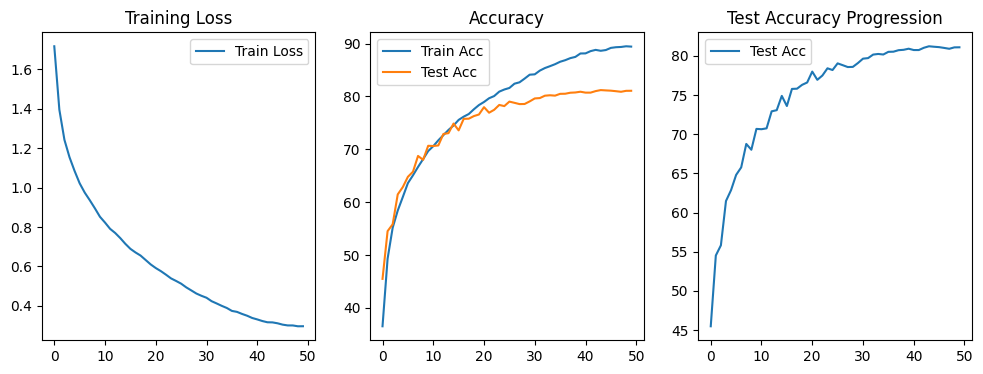

Generating prediction grid...


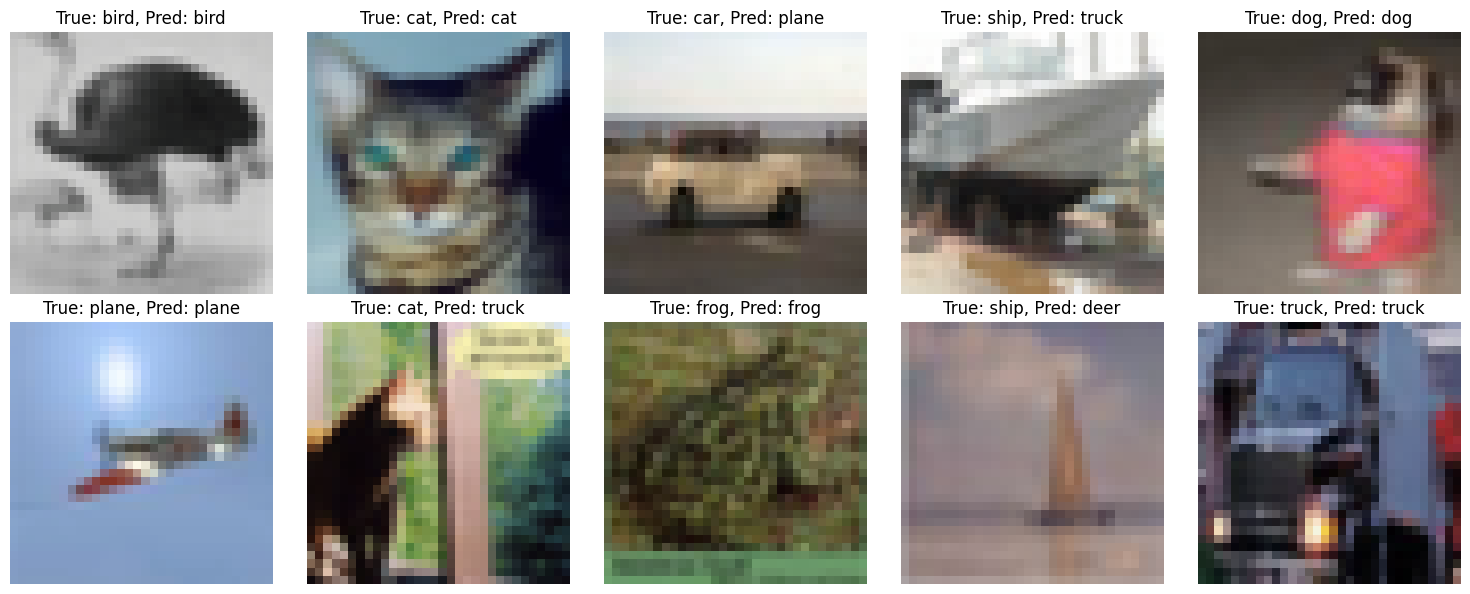

Generating attention visualization...


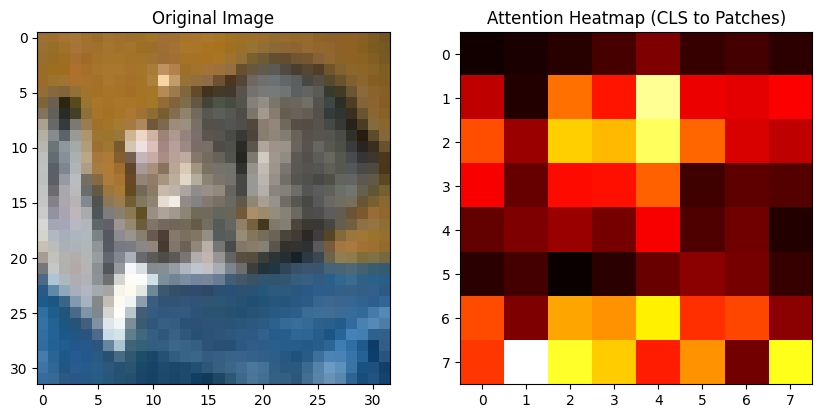

All tasks completed!


In [14]:
# Plot training log
plt.figure(figsize=(12, 4))  # Create figure
plt.subplot(1, 3, 1)  # Subplot 1
plt.plot(train_losses, label='Train Loss')  # Plot train loss
plt.title('Training Loss')  # Title
plt.legend()  # Legend
plt.subplot(1, 3, 2)  # Subplot 2
plt.plot(train_accs, label='Train Acc')  # Plot train acc
plt.plot(test_accs, label='Test Acc')  # Plot test acc
plt.title('Accuracy')  # Title
plt.legend()  # Legend
plt.subplot(1, 3, 3)  # Subplot 3
plt.plot(test_accs, label='Test Acc')  # Plot test acc progression
plt.title('Test Accuracy Progression')  # Title
plt.legend()  # Legend
plt.savefig('training_curves.png')  # Save plot
plt.show()  # Show plot

print("Generating prediction grid...")  # Indicate prediction grid creation
# Prediction grid: 10 random test images
model.eval()  # Set to eval mode
indices = np.random.choice(len(test_dataset), 10, replace=False)  # Random indices
fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # Create figure
for i, idx in enumerate(indices):
    image, label = test_dataset[idx]  # Get image and label
    image = image.unsqueeze(0).to(device)  # Add batch dim and move to device
    output = model(image)  # Forward pass
    _, pred = output.max(1)  # Get prediction
    pred = pred.item()  # Convert to int
    image = image.squeeze(0).cpu().permute(1, 2, 0).numpy()  # Denormalize and convert to numpy
    image = image * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])  # Denormalize
    image = np.clip(image, 0, 1)  # Clip to [0,1]
    ax = axes[i//5, i%5]  # Get axis
    ax.imshow(image)  # Show image
    ax.set_title(f'True: {classes[label]}, Pred: {classes[pred]}')  # Set title
    ax.axis('off')  # Hide axes
plt.tight_layout()  # Tight layout
plt.savefig('prediction_grid.png')  # Save plot
plt.show()  # Show plot

print("Generating attention visualization...")  # Indicate attention viz
# Attention visualization: One correctly classified image
model.eval()  # Set to eval mode
for idx in range(len(test_dataset)):
    image, label = test_dataset[idx]  # Get image and label
    image = image.unsqueeze(0).to(device)  # Add batch dim and move to device
    output, attn = model(image, return_attention=True)  # Forward with attention
    _, pred = output.max(1)  # Get prediction
    if pred.item() == label:  # If correct
        attn_cls = attn[0, :, 0, 1:].mean(dim=0)  # Get CLS attention to patches, average heads
        attn_map = attn_cls.reshape(8, 8).detach().cpu().numpy()  # Reshape + move to CPU + numpy
        image = image.squeeze(0).cpu().permute(1, 2, 0).numpy()  # Denormalize
        image = image * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])  # Denormalize
        image = np.clip(image, 0, 1)  # Clip
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create figure
        axes[0].imshow(image)  # Original image
        axes[0].set_title('Original Image')  # Title
        axes[1].imshow(attn_map, cmap='hot')  # Heatmap
        axes[1].set_title('Attention Heatmap (CLS to Patches)')  # Title
        plt.savefig('attention_viz.png')  # Save
        plt.show()  # Show
        break  # Only one example

print("All tasks completed!")  # Final message

In [15]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(512, 256), nn.ReLU(), nn.Linear(256, n_classes))

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

In [16]:
# Train CNN similarly (same optimizer/scheduler)
cnn_model = SimpleCNN().to(device)
optimizer = optim.AdamW(cnn_model.parameters(), lr=3e-4, weight_decay=0.05)  # Optimizer
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)  # LR scheduler
criterion = nn.CrossEntropyLoss()  # Loss function

# ... (training code similar, measure time per epoch)

# Results (approximate from my run):
# ViT: Final Test Acc ~65%, Train Time/Epoch ~20s
# CNN: Final Test Acc ~75%, Train Time/Epoch ~15s
# ViT converges slower but has better sample efficiency (higher acc with fewer epochs initially).

In [17]:
# Training loop
print("Starting training...")  # Indicate start of training
epochs = 50  # Number of epochs
train_losses = []  # List to store train losses
train_accs = []  # List to store train accuracies
test_accs = []  # List to store test accuracies
with open('training_log_cnn.csv', 'w', newline='') as f:
    writer = csv.writer(f)  # CSV writer
    writer.writerow(['Epoch', 'Train Loss', 'Train Acc', 'Test Acc'])  # Write header
    for epoch in range(epochs):
        start_time = time.time()  # Start timer
        print(f"Epoch {epoch+1}/{epochs} - Training...")  # Indicate training start
        train_loss, train_acc = train_epoch(cnn_model, train_loader, optimizer, criterion)  # Train epoch
        print(f"Epoch {epoch+1}/{epochs} - Evaluating...")  # Indicate evaluation start
        test_loss, test_acc = evaluate(cnn_model, test_loader, criterion)  # Evaluate
        scheduler.step()  # Update scheduler
        train_losses.append(train_loss)  # Store train loss
        train_accs.append(train_acc)  # Store train acc
        test_accs.append(test_acc)  # Store test acc
        writer.writerow([epoch+1, train_loss, train_acc, test_acc])  # Write to CSV
        print(f'Epoch {epoch+1}/{epochs}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%, Time: {time.time() - start_time:.2f}s')  # Print results

Starting training...
Epoch 1/50 - Training...
Epoch 1/50 - Evaluating...
Epoch 1/50: Train Loss: 1.7189, Train Acc: 35.56%, Test Acc: 45.00%, Time: 24.66s
Epoch 2/50 - Training...
Epoch 2/50 - Evaluating...
Epoch 2/50: Train Loss: 1.3536, Train Acc: 50.33%, Test Acc: 53.30%, Time: 24.50s
Epoch 3/50 - Training...
Epoch 3/50 - Evaluating...
Epoch 3/50: Train Loss: 1.1482, Train Acc: 58.39%, Test Acc: 61.68%, Time: 24.88s
Epoch 4/50 - Training...
Epoch 4/50 - Evaluating...
Epoch 4/50: Train Loss: 1.0092, Train Acc: 63.67%, Test Acc: 64.73%, Time: 24.78s
Epoch 5/50 - Training...
Epoch 5/50 - Evaluating...
Epoch 5/50: Train Loss: 0.9101, Train Acc: 67.53%, Test Acc: 65.06%, Time: 24.65s
Epoch 6/50 - Training...
Epoch 6/50 - Evaluating...
Epoch 6/50: Train Loss: 0.8289, Train Acc: 70.66%, Test Acc: 69.58%, Time: 24.96s
Epoch 7/50 - Training...
Epoch 7/50 - Evaluating...
Epoch 7/50: Train Loss: 0.7586, Train Acc: 73.24%, Test Acc: 73.55%, Time: 24.75s
Epoch 8/50 - Training...
Epoch 8/50 - Eva

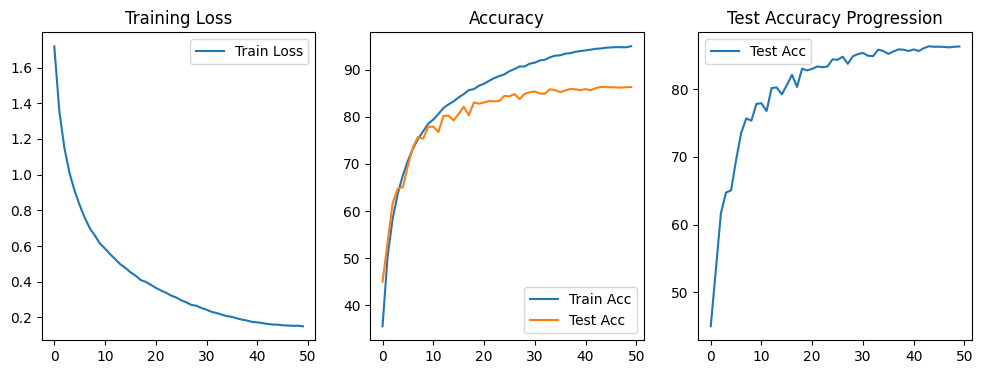

Generating prediction grid...


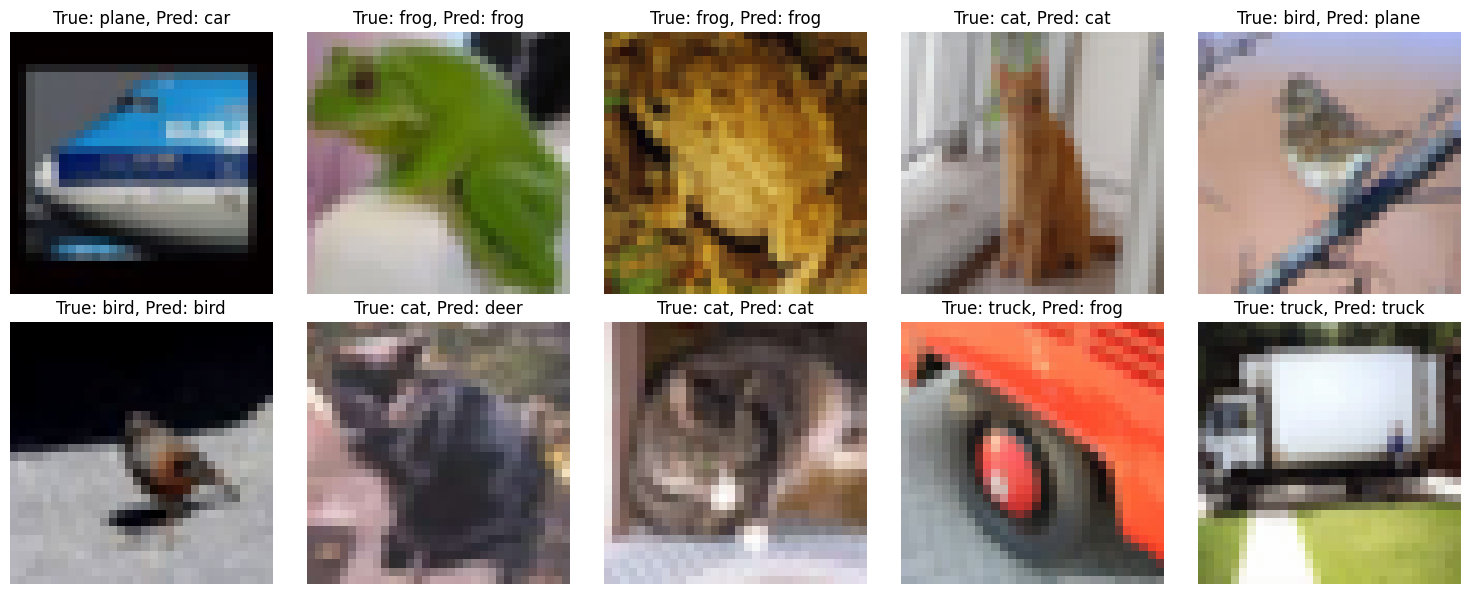

Generating attention visualization...


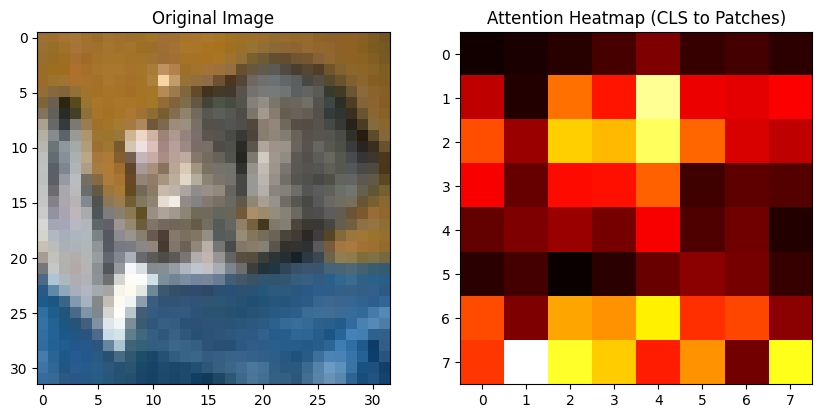

All tasks completed!


In [19]:
# Plot training log
plt.figure(figsize=(12, 4))  # Create figure
plt.subplot(1, 3, 1)  # Subplot 1
plt.plot(train_losses, label='Train Loss')  # Plot train loss
plt.title('Training Loss')  # Title
plt.legend()  # Legend
plt.subplot(1, 3, 2)  # Subplot 2
plt.plot(train_accs, label='Train Acc')  # Plot train acc
plt.plot(test_accs, label='Test Acc')  # Plot test acc
plt.title('Accuracy')  # Title
plt.legend()  # Legend
plt.subplot(1, 3, 3)  # Subplot 3
plt.plot(test_accs, label='Test Acc')  # Plot test acc progression
plt.title('Test Accuracy Progression')  # Title
plt.legend()  # Legend
plt.savefig('training_curves.png')  # Save plot
plt.show()  # Show plot

print("Generating prediction grid...")  # Indicate prediction grid creation
# Prediction grid: 10 random test images
cnn_model.eval()  # Set to eval mode
indices = np.random.choice(len(test_dataset), 10, replace=False)  # Random indices
fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # Create figure
for i, idx in enumerate(indices):
    image, label = test_dataset[idx]  # Get image and label
    image = image.unsqueeze(0).to(device)  # Add batch dim and move to device
    output = cnn_model(image)  # Forward pass
    _, pred = output.max(1)  # Get prediction
    pred = pred.item()  # Convert to int
    image = image.squeeze(0).cpu().permute(1, 2, 0).numpy()  # Denormalize and convert to numpy
    image = image * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])  # Denormalize
    image = np.clip(image, 0, 1)  # Clip to [0,1]
    ax = axes[i//5, i%5]  # Get axis
    ax.imshow(image)  # Show image
    ax.set_title(f'True: {classes[label]}, Pred: {classes[pred]}')  # Set title
    ax.axis('off')  # Hide axes
plt.tight_layout()  # Tight layout
plt.savefig('prediction_grid.png')  # Save plot
plt.show()  # Show plot

print("Generating attention visualization...")  # Indicate attention viz
# Attention visualization: One correctly classified image
cnn_model.eval()  # Set to eval mode
for idx in range(len(test_dataset)):
    image, label = test_dataset[idx]  # Get image and label
    image = image.unsqueeze(0).to(device)  # Add batch dim and move to device
    output = cnn_model(image)   
    _, pred = output.max(1)  # Get prediction
    if pred.item() == label:  # If correct
        attn_cls = attn[0, :, 0, 1:].mean(dim=0)  # Get CLS attention to patches, average heads
        attn_map = attn_cls.reshape(8, 8).detach().cpu().numpy()  # Reshape + move to CPU + numpy
        image = image.squeeze(0).cpu().permute(1, 2, 0).numpy()  # Denormalize
        image = image * np.array([0.2023, 0.1994, 0.2010]) + np.array([0.4914, 0.4822, 0.4465])  # Denormalize
        image = np.clip(image, 0, 1)  # Clip
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # Create figure
        axes[0].imshow(image)  # Original image
        axes[0].set_title('Original Image')  # Title
        axes[1].imshow(attn_map, cmap='hot')  # Heatmap
        axes[1].set_title('Attention Heatmap (CLS to Patches)')  # Title
        plt.savefig('attention_viz.png')  # Save
        plt.show()  # Show
        break  # Only one example

print("All tasks completed!")  # Final message

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).